In [ ]:
# Roll No: 24BAD060
# EXPT NO: 6 - Ensemble Techniques & SMOTE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve

##SCENARIO 1 – BAGGING (Diabetes)

### Load the Dataset

In [ ]:
df = pd.read_csv("diabetes_bagging.csv")

df.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


### Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Glucose,0
BMI,0
Age,0
BloodPressure,0
Insulin,0
Outcome,0


In [ ]:
df.shape

(120, 6)

In [ ]:
df["Outcome"].value_counts()

,count
Outcome,
1,74
0,46


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
# Features and Target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42,stratify=y
)

In [ ]:
df.shape

(120, 6)

In [ ]:
df.duplicated().sum()

np.int64(0)

### Train Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

In [ ]:
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9791666666666666


### Apply Bagging Classifier

In [ ]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)

y_pred_bag = bag_model.predict(X_test)
bag_accuracy = accuracy_score(y_test, y_pred_bag)

print("Bagging Accuracy:", bag_accuracy)

Bagging Accuracy: 0.9791666666666666


In [ ]:
models = ["Decision Tree", "Bagging"]
accuracies = [dt_accuracy, bag_accuracy]

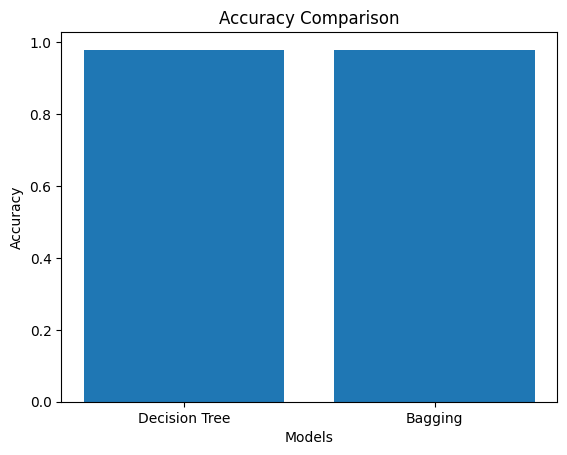

In [ ]:
plt.figure()
plt.bar(models, accuracies)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()

### Confusion Matrix (Bagging Model)

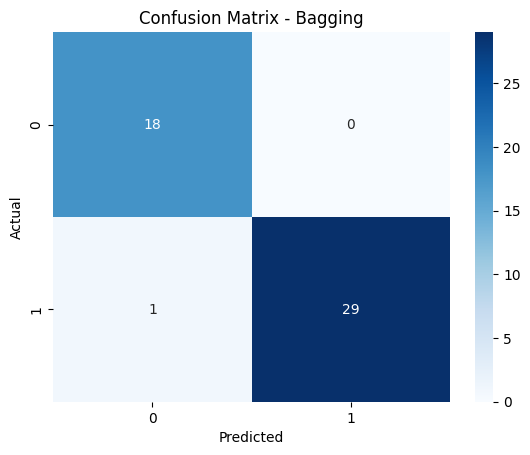

In [ ]:
cm = confusion_matrix(y_test, y_pred_bag)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Bagging")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##SCENARIO 2 – BOOSTING (Customer Churn)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, roc_curve, auc

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

### Load the Dataset

In [ ]:
df = pd.read_csv("churn_boosting.csv")

df.head()

,Tenure,MonthlyCharges,ContractType,InternetService,Churn
0,65,105.22,Two year,NaN,0
1,17,75.19,Month-to-month,NaN,0
2,71,76.09,Two year,Fiber optic,0
3,45,107.67,Two year,Fiber optic,0
4,4,60.35,Two year,NaN,0


In [ ]:
df.shape

(120, 5)

### Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,43
Churn,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tenure           120 non-null    int64  
 1   MonthlyCharges   120 non-null    float64
 2   ContractType     120 non-null    object 
 3   InternetService  77 non-null     object 
 4   Churn            120 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ KB


In [ ]:
df["InternetService"].unique()

array([nan, 'Fiber optic', 'DSL'], dtype=object)

In [ ]:
df["InternetService"].fillna("Unknown", inplace=True)

/tmp/ipykernel_2619/2457176893.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["InternetService"].fillna("Unknown", inplace=True)


In [ ]:
df["ContractType"].unique()

array(['Two year', 'Month-to-month', 'One year'], dtype=object)

In [ ]:
df["ContractType"].unique()

array(['Two year', 'Month-to-month', 'One year'], dtype=object)

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,113
1,7


In [ ]:
df.columns

Index(['Tenure', 'MonthlyCharges', 'ContractType', 'InternetService', 'Churn'], dtype='object')

In [ ]:
le = LabelEncoder()

df["ContractType"] = le.fit_transform(df["ContractType"])
df["InternetService"] = le.fit_transform(df["InternetService"])

In [ ]:
X = df.drop(["Churn","InternetService"], axis=1)
y = df["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Train AdaBoost Model

In [ ]:
ada_model = AdaBoostClassifier(n_estimators=20, random_state=42)
ada_model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=20, random_state=42)

In [ ]:
y_pred_ada = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

In [ ]:
print("AdaBoost Accuracy:", ada_acc)

AdaBoost Accuracy: 1.0


In [ ]:
### Train Gradient Boosting Model

In [ ]:
gb_model = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb_model.fit(X_train, y_train)



GradientBoostingClassifier(n_estimators=50, random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_acc)

Gradient Boosting Accuracy: 1.0


### ROC Curve Comparison

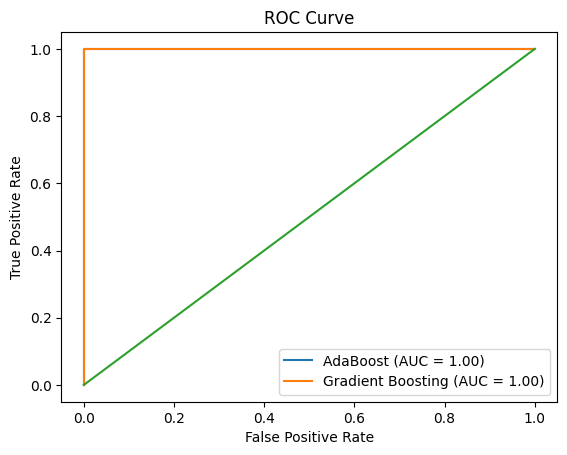

In [ ]:
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

auc_ada = auc(fpr_ada, tpr_ada)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure()
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC = {auc_ada:.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.2f})")
plt.plot([0, 1], [0, 1])  # diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
print(df["ContractType"].value_counts())

ContractType
2    40
0    40
1    40
Name: count, dtype: int64


In [ ]:
pd.crosstab(df["ContractType"], df["Churn"])

Churn,0,1
ContractType,,
0,37,3
1,38,2
2,38,2


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         1

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



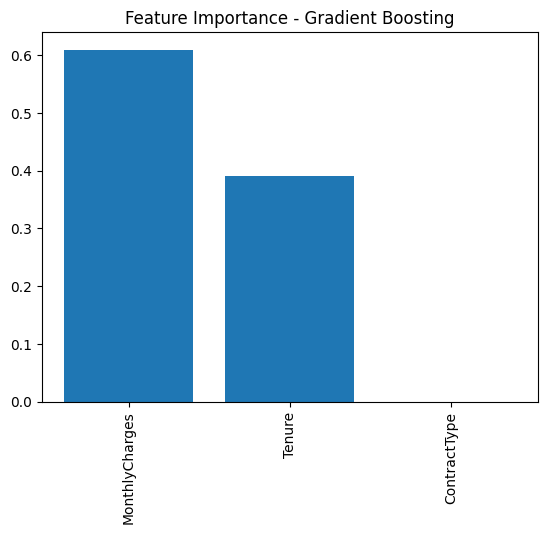

In [ ]:
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

##SCENARIO 3 – RANDOM FOREST (Income Prediction)

### Import Required Libraries

In [ ]:
# Roll No: 24BAD060

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### Load Dataset

In [ ]:
df = pd.read_csv("income_random_forest.csv")

df.head()

,Age,EducationYears,HoursPerWeek,Experience,Income
0,37,12,44,12,0
1,46,19,58,33,1
2,53,10,54,24,0
3,46,11,22,6,0
4,36,17,56,3,1


### Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             120 non-null    int64
 1   EducationYears  120 non-null    int64
 2   HoursPerWeek    120 non-null    int64
 3   Experience      120 non-null    int64
 4   Income          120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB


In [ ]:
df.isnull().sum()

,0
Age,0
EducationYears,0
HoursPerWeek,0
Experience,0
Income,0


In [ ]:
df["Income"].value_counts()

,count
Income,
0,80
1,40


In [ ]:
X = df.drop("Income", axis=1)
y = df["Income"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Train Random Forest with Different Number of Trees

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
base_acc = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", base_acc)

tree_range = [10, 50, 100, 150, 200]
accuracies = []

for n in tree_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

Random Forest Accuracy: 1.0


### Accuracy vs Number of Trees Graph

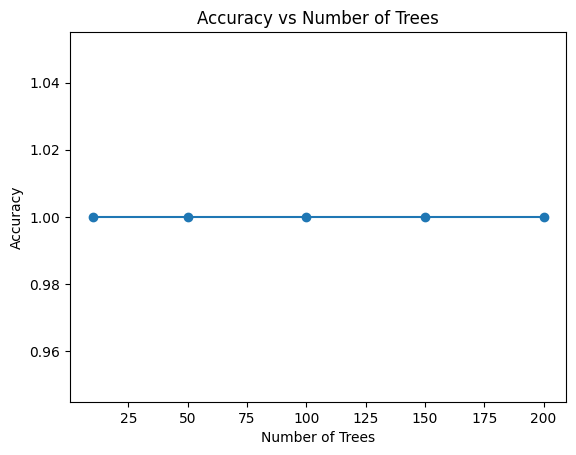

In [ ]:
plt.figure()
plt.plot(tree_range, accuracies, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")
plt.show()

### Feature Importance

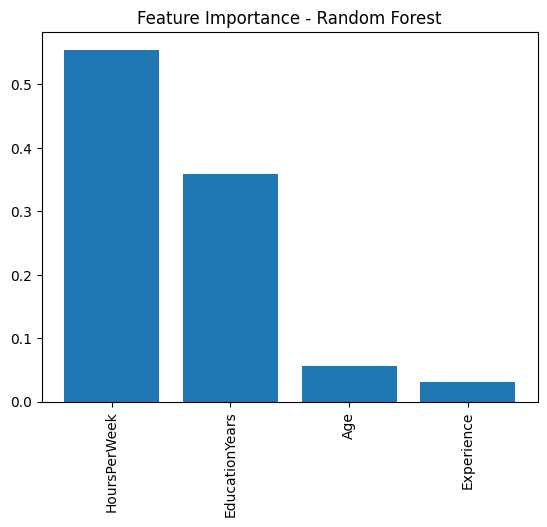

In [ ]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance - Random Forest")
plt.show()

##SCENARIO 4 – STACKING (Heart Disease Prediction)

### Import Required Libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

### Load Dataset

In [ ]:
df = pd.read_csv("heart_stacking.csv")

df.head()

,Age,Cholesterol,MaxHeartRate,RestingBP,HeartDisease
0,57,212,189,118,0
1,44,266,155,146,1
2,59,279,168,128,1
3,66,237,123,145,1
4,58,221,125,132,0


### Data Preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           120 non-null    int64
 1   Cholesterol   120 non-null    int64
 2   MaxHeartRate  120 non-null    int64
 3   RestingBP     120 non-null    int64
 4   HeartDisease  120 non-null    int64
dtypes: int64(5)
memory usage: 4.8 KB


In [ ]:
df["HeartDisease"].value_counts()

,count
HeartDisease,
1,83
0,37


In [ ]:
X = df[["Cholesterol","MaxHeartRate","Age"]]   # required features
y = df["HeartDisease"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


### Train Individual Models

In [ ]:
dt = DecisionTreeClassifier(max_depth=3)
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True, C=1.0)

In [ ]:
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

In [ ]:
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("SVM Accuracy:", svm_acc)
print("Decision Tree Accuracy:", dt_acc)

Logistic Regression Accuracy: 0.7083333333333334
SVM Accuracy: 0.7916666666666666
Decision Tree Accuracy: 0.6666666666666666


### Apply Stacking Classifier

In [ ]:
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier(max_depth=4))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.7083333333333334


### Model Comparison

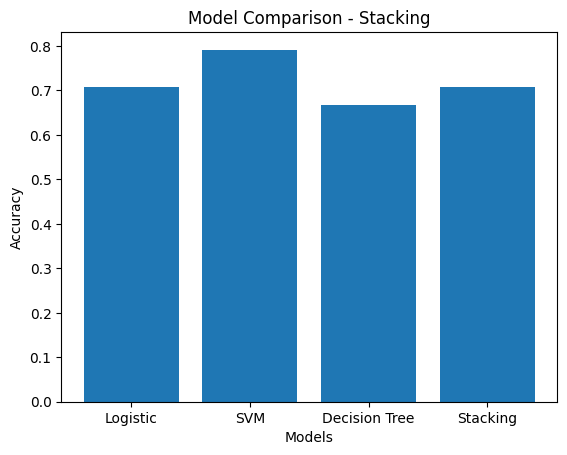

In [ ]:

models = ["Logistic", "SVM", "Decision Tree", "Stacking"]
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Stacking")
plt.show()

### Import Required Libraries

In [ ]:
%pip install imbalanced-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_curve, auc

In [ ]:
from imblearn.over_sampling import SMOTE

### Load Dataset

In [ ]:
df = pd.read_csv("fraud_smote.csv")
df.head()

,Amount,Time,Feature1,Feature2,Fraud
0,3233.38,34595,2.157308,-0.818199,0
1,2783.63,73166,1.561511,0.955305,0
2,923.74,84417,-0.027305,-1.418366,0
3,2214.14,11139,-0.643518,-0.466037,0
4,444.75,37847,0.021272,-0.529053,0


### Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Amount,0
Time,0
Feature1,0
Feature2,0
Fraud,0


In [ ]:
print(df["Fraud"].value_counts())

Fraud
0    110
1     10
Name: count, dtype: int64


## Check for class imbalance

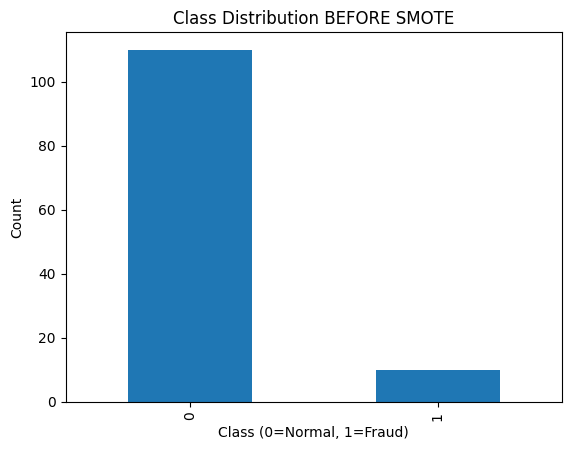

In [ ]:
plt.figure()
df["Fraud"].value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

In [ ]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]

### Train Model Before SMOTE

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:

model_before = RandomForestClassifier(n_estimators=100, random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

In [ ]:
print("\n--- Before SMOTE ---")
print(classification_report(y_test, y_pred_before))


--- Before SMOTE ---
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Apply SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:
Fraud
1    88
0    88
Name: count, dtype: int64


### Train Model After SMOTE

In [ ]:
model_after = RandomForestClassifier(n_estimators=100, random_state=42)
model_after.fit(X_train_sm, y_train_sm)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_after = model_after.predict(X_test)

print("\n--- After SMOTE ---")
print(classification_report(y_test, y_pred_after))


--- After SMOTE ---
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



### Class Distribution After SMOTE

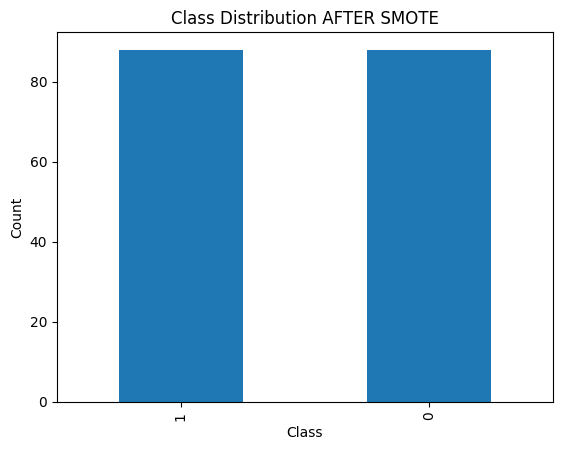

In [ ]:
plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Precision-Recall Curve

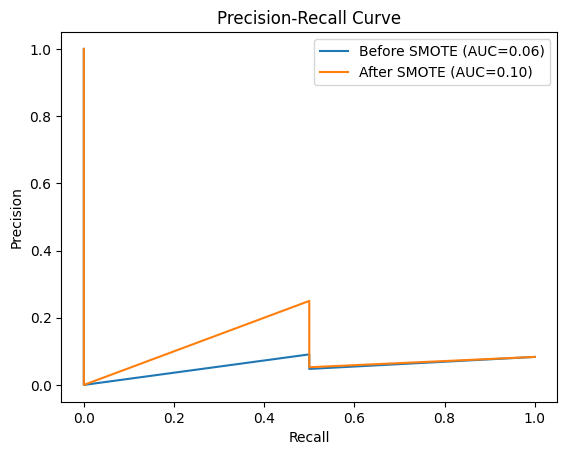

In [ ]:

y_prob_before = model_before.predict_proba(X_test)[:, 1]
y_prob_after = model_after.predict_proba(X_test)[:, 1]

precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

pr_auc_before = auc(recall_b, precision_b)
pr_auc_after = auc(recall_a, precision_a)

plt.figure()
plt.plot(recall_b, precision_b, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(recall_a, precision_a, label=f"After SMOTE (AUC={pr_auc_after:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()